#### Exercise 1
Ahmet Meriç Kızıltaş

**a)** *Read the given oldtimer.png image. Convert it to HSV color space, and create a grayscale
version by retaining only the value. (3P)*


In [4]:
!mamba install scikit-image
!mamba install imageio

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, scikit-image
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.021 seconds
All requested packages already installed.
mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, scikit-image, imageio
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.37310000002384186 seconds
All requested packages already installed.


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import skimage as ski
import imageio

/tmp/xpython_42/1815846468.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image_rgb = imageio.imread("oldtimer.png")


(388, 640)


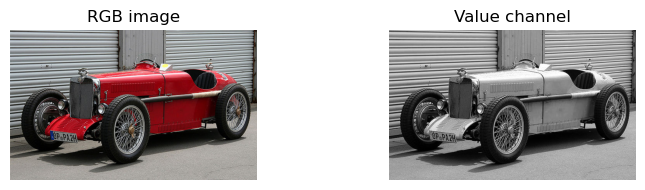

In [26]:
image_rgb = imageio.imread("oldtimer.png")
image_hsv = ski.color.rgb2hsv(image_rgb)
image_value = image_hsv[:, :, 2]


fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(8, 2))

ax0.imshow(image_rgb)
ax0.set_title("RGB image")
ax0.axis('off')
ax1.imshow(image_value, cmap='gray')
ax1.set_title("Value channel")
ax1.axis('off')

fig.tight_layout()

**b)** *Think about another way to convert color image to grayscale. Its result should look reasonable
(with bright regions appearing bright), but it should differ from the one you obtained from the
HSV color space. Implement and briefly justify your method. (3P)*

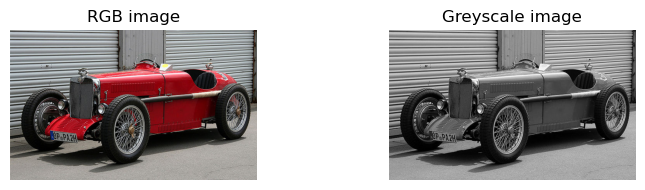

In [29]:
image_red = image_rgb[:,:,0]
image_green = image_rgb[:,:,1]
image_blue = image_rgb[:,:,2]
image_gray = (0.5*image_red+0.3*image_green+0.2*image_blue)

fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(8, 2))

ax0.imshow(image_rgb)
ax0.set_title("RGB image")
ax0.axis('off')
ax1.imshow(image_gray, cmap='gray')
ax1.set_title("Greyscale image")
ax1.axis('off')

fig.tight_layout()

I have implemented an grayscale image by averaging the three color channels. I have chosen the coefficients
0.5 for red, 0.3 for green, and 0.2 for blue by trying out different possibilities and choosing the one which provides better results. This method preserves bright and dark regions because white and grey are obtained respectively by high and low values on all three channels at the same time.

**c)** *Output a version of the image in which saturation has been reduced by 50%. (2P)*


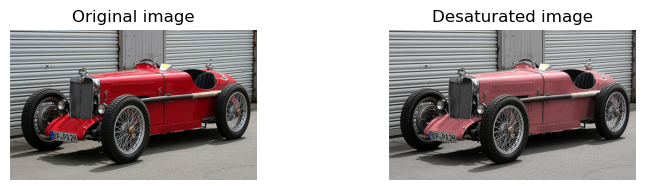

In [32]:
image_value = image_hsv[:, :, 2]
image_hue = image_hsv[:, :, 0]
image_sat = image_hsv[:, :, 1]
image_sat = 0.5*image_sat

image_desat = np.array([image_hue, image_sat, image_value])
image_desat = np.transpose(image_desat, (1, 2, 0))
image_desat = ski.color.hsv2rgb(image_desat)
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(8, 2))

ax0.imshow(image_rgb)
ax0.set_title("Original image")
ax0.axis('off')
ax1.imshow(image_desat)
ax1.set_title("Desaturated image")
ax1.axis('off')

fig.tight_layout()

**d)** *Create a simple “aged photograph” effect by globally blending (via simple weighted averaging or
some other blend mode of your choice) the half-desaturated image from the previous step with
some amount of brown. (2P)*

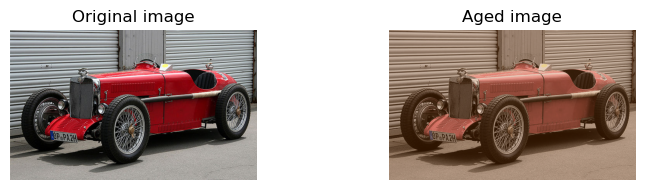

In [43]:
brown = np.array([[[0.7, 0.3, 0]]])
image_brown = np.repeat(brown, image_rgb.shape[0], axis=0)
image_brown = np.repeat(image_brown, image_rgb.shape[1], axis=1)

image_aged = 0.75*image_desat + 0.25*image_brown

fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(8, 2))

ax0.imshow(image_rgb)
ax0.set_title("Original image")
ax0.axis('off')
ax1.imshow(image_aged)
ax1.set_title("Aged image")
ax1.axis('off')

fig.tight_layout()

**e)** *Rotate the hues of the original image so that the car obtains a different color. Provide two images
in which the car is blue, and has another color of your choice. (4P)*

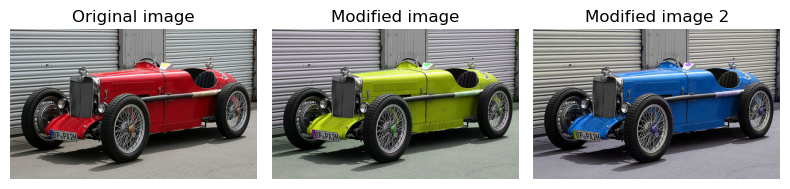

In [49]:

image_value = image_hsv[:, :, 2]
image_hue = image_hsv[:, :, 0]
image_sat = image_hsv[:, :, 1]
def mod_matrix(m ,r):
    g = lambda x: x+r if x+r<=1. else x+r-1
    return np.vectorize(g)(m)
image_hue_2 = mod_matrix(image_hue, 0.2)
image_hue_3 = mod_matrix(image_hue, 0.6)

image_switched_1 = np.array([image_hue_2, image_sat, image_value])
image_switched_1 = np.transpose(image_switched_1, (1, 2, 0))
image_switched_1 = ski.color.hsv2rgb(image_switched_1)

image_switched_2 = np.array([image_hue_3, image_sat, image_value])
image_switched_2 = np.transpose(image_switched_2, (1, 2, 0))
image_switched_2 = ski.color.hsv2rgb(image_switched_2)

fig, (ax0, ax1, ax2) = plt.subplots(ncols=3, figsize=(8, 2))

ax0.imshow(image_rgb)
ax0.set_title("Original image")
ax0.axis('off')
ax1.imshow(image_switched_1)
ax1.set_title("Modified image")
ax1.axis('off')
ax2.imshow(image_switched_2)
ax2.set_title("Modified image 2")
ax2.axis('off')

fig.tight_layout()